In [1]:
import os
import zipfile
import pyarrow.parquet as pq
import pandas as pd

folder = r"F:\sanazi\python\data science\code\tamrin\proje\Tennis Schema\Tennis Schema\tennis_data"

data = {}

for file in os.listdir(folder): 
    if file.endswith(".zip"): 
        zip_path = os.path.join(folder, file) 

        with zipfile.ZipFile(zip_path) as z: 
            for parquet_file in z.namelist():
                if parquet_file.endswith(".parquet"): 

                    with z.open(parquet_file) as f: 
                        df = pq.read_table(f).to_pandas()
                    table_name =os.path.basename(os.path.dirname(parquet_file))[4:-8] + os.path.basename(parquet_file)[:-17] 

                    if table_name not in data:
                        data[table_name] = [] 
                    data[table_name].append(df) 


for table_name in data:
    data[table_name] = pd.concat(data[table_name], ignore_index=True)

print(data.keys())

C:\Users\sepehr\AppData\Local\Temp\ipykernel_14072\661795369.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data[table_name] = pd.concat(data[table_name], ignore_index=True)


dict_keys(['matchaway_team', 'matchaway_team_score', 'matchevent', 'matchhome_team', 'matchhome_team_score', 'matchround', 'matchseason', 'matchtime', 'matchtournament', 'matchvenue', 'oddsodds', 'point_by_pointpbp', 'statisticsstatistics', 'tennis_powerpower', 'votesvotes'])


In [2]:
print(data["matchhome_team"].columns)

Index(['match_id', 'name', 'slug', 'gender', 'user_count', 'residence',
       'birthplace', 'height', 'weight', 'plays', 'turned_pro',
       'current_prize', 'total_prize', 'player_id', 'current_rank',
       'name_code', 'country', 'full_name'],
      dtype='object')


In [3]:
print(data["matchhome_team"]["plays"].unique())

['right-handed' 'left-handed' None]


In [4]:
import pandas as pd
import numpy as np


tournament = data["matchtournament"][["match_id", "ground_type"]]
event = data["matchevent"][["match_id", "winner_code"]]

home = data["matchhome_team"][["match_id", "plays"]].rename(
    columns={"plays": "home_hand"}
)

away = data["matchaway_team"][["match_id", "plays"]].rename(
    columns={"plays": "away_hand"}
)


df = tournament.merge(event, on="match_id")
df = df.merge(home, on="match_id")
df = df.merge(away, on="match_id")


df = df[df["ground_type"] == "Grass"]


df = df.dropna(subset=["home_hand", "away_hand"])


df["winner_hand"] = np.where(
    df["winner_code"] == 1,
    df["home_hand"],
    df["away_hand"]
)


wins = df["winner_hand"].value_counts()

print(wins)

winner_hand
right-handed    256
left-handed     128
Name: count, dtype: int64


In [5]:
print(df["winner_hand"].value_counts(normalize=True) * 100)

winner_hand
right-handed    66.666667
left-handed     33.333333
Name: proportion, dtype: float64


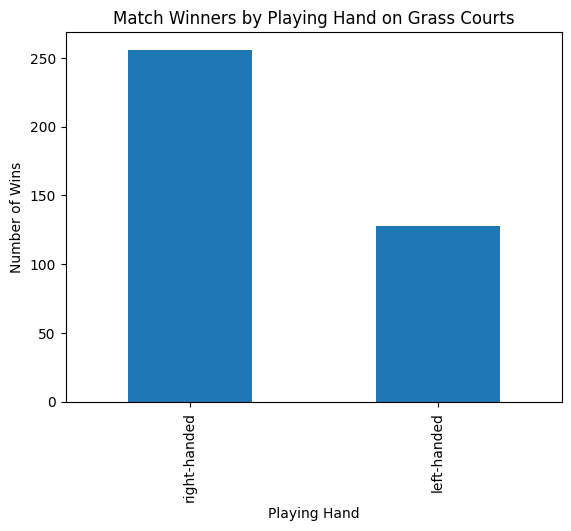

In [6]:
import matplotlib.pyplot as plt

wins.plot(kind="bar")

plt.title("Match Winners by Playing Hand on Grass Courts")
plt.xlabel("Playing Hand")
plt.ylabel("Number of Wins")

plt.show()